In [1]:
import os

os.chdir("..")
os.getcwd()

'/home/borealis/Documents/work/projects/work_tests/SpeakVer'

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T

from src.data.audio_preprocessor import AudioPreprocessor
from src.model.embedding_extractor import EmbeddingExtractor


In [3]:
MAX_BATCH_SIZE = 64
MIN_BATCH_SIZE = 4
TARGET_SR = 8000

# Paths
TRAIN_PATH = "speaker_dataset_new/train"
VAL_PATH = "speaker_dataset_new/val"
TEST_PATH = "speaker_dataset_new/test"
LENGTHS_CACHE_PATH = "speaker_dataset_new/lengths_cache.pkl"

MIC_TYPE = "throat_microphone"

In [4]:
train_preprocessor = AudioPreprocessor(
    resample=True,
    augment=True,
    fix_length=False,
    target_sr=TARGET_SR,
    vad_search_time=0.05,
    vad_trigger_level=12,
    target_peak=0.9
)
val_preprocessor = AudioPreprocessor(
    resample=True,
    augment=False,
    fix_length=False,
    target_sr=TARGET_SR,
    vad_search_time=0.05,
    vad_trigger_level=12,
    target_peak=0.9
)
test_preprocessor = AudioPreprocessor(
    resample=True,
    augment=False,
    fix_length=False,
    target_sr=TARGET_SR,
    vad_search_time=0.05,
    vad_trigger_level=12,
    target_peak=0.9
)

In [5]:
model = EmbeddingExtractor(device="cpu")

checkpoint = torch.load(
    "runs/exp1_sched_unfreeze_named_modules_batch64_epochs100_no_balance_cosanwarm_dyn_batch_throat_mic/weights/best.pt"
)
model.load_state_dict(checkpoint["encoder"])

<All keys matched successfully>

In [6]:
test_audio = "debug_audio/22445.wav"

In [7]:
test_preprocessor.peak_normalize = False
test_preprocessor.vad = False
test_preprocessor.remove_dc = False
original = test_preprocessor(test_audio)
original

{'waveform': tensor([[-3.3103e-04, -6.9752e-04, -7.3343e-04,  ...,  2.4574e-04,
           9.5655e-05,  1.2257e-04]]),
 'init_rate': 48000,
 'target_rate': 8000,
 'length': 25256}

In [8]:
test_preprocessor.peak_normalize = True
test_preprocessor.vad = True
test_preprocessor.remove_dc = True
test_preprocessor.augment = True
processing = test_preprocessor(test_audio)

torchaudio.save(
    "debug_audio/test.wav", processing["waveform"], processing["target_rate"]
)
processing

{'waveform': tensor([[-5.1841e-03, -1.3153e-02, -8.4681e-03,  ..., -4.0762e-05,
           1.3980e-03,  8.5619e-03]]),
 'init_rate': 48000,
 'target_rate': 8000,
 'length': 25256}

In [9]:
def compare_audio(
    waveform_original,
    waveform_processed,
    sample_rate=8000,
):
    mel = T.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=512,
        win_length=400,
        hop_length=160,
        n_mels=80,
    )

    db = T.AmplitudeToDB()

    mel_original = db(mel(waveform_original))
    mel_processed = db(mel(waveform_processed))

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 8),
        constrained_layout=True,
    )

    # --------------------------------------------------------
    # Waveforms
    # --------------------------------------------------------

    axes[0, 0].plot(
        waveform_original.squeeze().numpy(),
    )
    axes[0, 0].set_title("Original waveform")
    axes[0, 0].set_xlabel("Samples")
    axes[0, 0].set_ylabel("Amplitude")

    axes[0, 1].plot(
        waveform_processed.squeeze().numpy(),
    )
    axes[0, 1].set_title("Processed waveform")
    axes[0, 1].set_xlabel("Samples")
    axes[0, 1].set_ylabel("Amplitude")

    # --------------------------------------------------------
    # Spectrograms
    # --------------------------------------------------------

    im1 = axes[1, 0].imshow(
        mel_original.squeeze().numpy(),
        origin="lower",
        aspect="auto",
    )

    axes[1, 0].set_title("Original Log-Mel")
    axes[1, 0].set_xlabel("Frames")
    axes[1, 0].set_ylabel("Mel bins")

    im2 = axes[1, 1].imshow(
        mel_processed.squeeze().numpy(),
        origin="lower",
        aspect="auto",
    )

    axes[1, 1].set_title("Processed Log-Mel")
    axes[1, 1].set_xlabel("Frames")
    axes[1, 1].set_ylabel("Mel bins")

    fig.colorbar(
        im1,
        ax=axes[1, 0],
    )

    fig.colorbar(
        im2,
        ax=axes[1, 1],
    )

    plt.show()

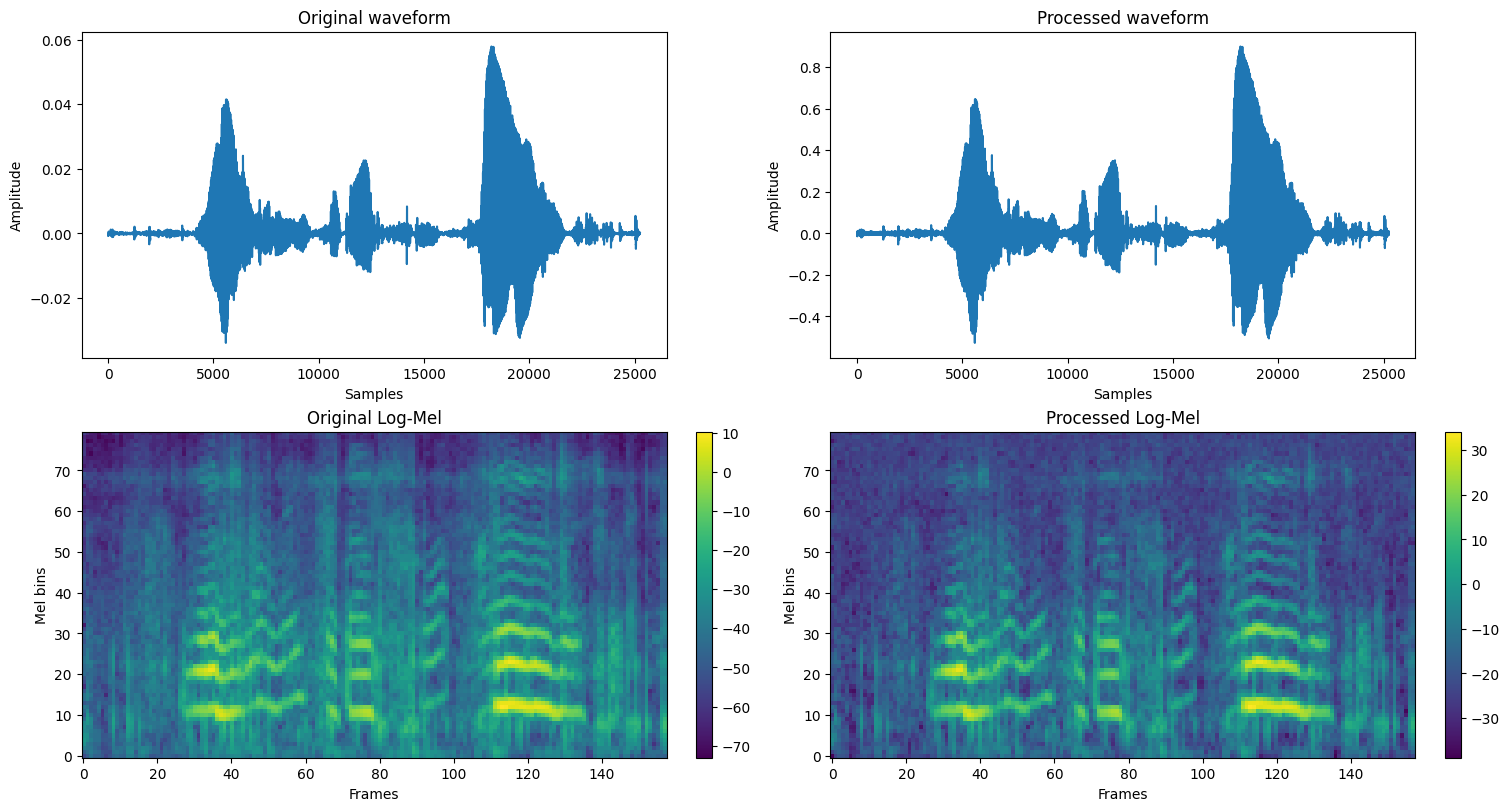

In [10]:
compare_audio(
    original["waveform"],
    processing["waveform"],
    original["target_rate"],
)

In [11]:
print(f"Ratio lengths: {(original["length"] / processing["length"]):.4}")

Ratio lengths: 1.0


In [12]:
print(f"Min clipping: {processing["waveform"].min().item():.3}")
print(f"Max clipping: {processing["waveform"].max().item():.3}")

Min clipping: -0.527
Max clipping: 0.9


In [13]:
print(f"RMS original: {original["waveform"].pow(2).mean().sqrt():.3}")
print(f"RMS processed: {processing["waveform"].pow(2).mean().sqrt():.3}")

RMS original: 0.00756
RMS processed: 0.118


In [14]:
print(f"Peak original: {original["waveform"].abs().max():.3}")
print(f"Peak processed: {processing["waveform"].abs().max():.3}")

Peak original: 0.0579
Peak processed: 0.9


In [15]:
print(f"DC original: {original["waveform"].mean():.3}")
print(f"DC processed: {processing["waveform"].mean():.3}")

DC original: -4.48e-06
DC processed: -4.36e-06


In [16]:
original["waveform"], processing["waveform"]

(tensor([[-3.3103e-04, -6.9752e-04, -7.3343e-04,  ...,  2.4574e-04,
           9.5655e-05,  1.2257e-04]]),
 tensor([[-5.1841e-03, -1.3153e-02, -8.4681e-03,  ..., -4.0762e-05,
           1.3980e-03,  8.5619e-03]]))

In [17]:
original_emb = model(original["waveform"])
processed_emb = model(processing["waveform"])

cos_sim = F.cosine_similarity(
    original_emb,
    processed_emb,
    dim=1,
).item()

print(f"Cosine similarity of the same speakers: {cos_sim:.3}")

Cosine similarity of the same speakers: 0.863


In [18]:
from src.model.aamsoftmax import AAMSoftmax

classifier = AAMSoftmax(
    embedding_dim=192,
    num_classes=149,
    margin=0.3,
    scale=30
)

classifier.load_state_dict(
    checkpoint["classifier"]
)
loss, logits = classifier(
    torch.stack([original_emb, processed_emb]).squeeze_(1), 
    torch.tensor([1, 1])
)
test = torch.argmax(logits[0]) == torch.argmax(logits[1])
test.item()

False